In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("feature_engineered_dataset.csv")

In [ ]:
df.shape # rows and columns

(73100, 31)

In [ ]:
df.info() # column names, datatypes, null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                73100 non-null  object 
 1   store_id            73100 non-null  object 
 2   product_id          73100 non-null  object 
 3   category            73100 non-null  object 
 4   region              73100 non-null  object 
 5   inventory_level     73100 non-null  int64  
 6   units_sold          73100 non-null  int64  
 7   units_ordered       73100 non-null  int64  
 8   demand_forecast     73100 non-null  float64
 9   price               73100 non-null  float64
 10  discount            73100 non-null  float64
 11  weather_condition   73100 non-null  object 
 12  holiday/promotion   73100 non-null  int64  
 13  competitor_pricing  73100 non-null  float64
 14  seasonality         73100 non-null  object 
 15  visitors            73100 non-null  int64  
 16  cost

In [ ]:
df.describe() # min, max, mean, std for numeric columns

,inventory_level,units_sold,units_ordered,demand_forecast,price,discount,holiday/promotion,competitor_pricing,visitors,cost,...,competitor_gap,discounted_price,revenue,conversion_rate,price_demand_ratio,stock_remaining,traffic_intensity,day_of_week,month,is_weekend
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,...,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,0.100095,0.497305,55.146077,310.810903,35.835519,...,-0.010969,49.613573,6771.154240,0.395607,1.590373,138.005007,1.382678,3.002736,6.518468,0.287278
std,129.949514,108.919406,52.277448,109.254076,26.021945,0.070837,0.499996,26.191408,130.423074,17.718792,...,2.888538,23.801649,6815.600468,0.216673,5.336459,109.766664,0.831000,2.003429,3.451564,0.452495
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000,51.000000,5.050000,...,-5.000000,8.008000,0.000000,0.000000,0.020782,0.000000,0.107368,0.000000,1.000000,0.000000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,0.050000,0.000000,32.680000,215.000000,20.877500,...,-2.530000,29.210000,1811.012000,0.218391,0.228771,49.000000,0.851639,1.000000,4.000000,0.000000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,0.100000,0.000000,55.010000,297.000000,35.130000,...,0.000000,49.172500,4444.157500,0.395248,0.464449,109.000000,1.195190,3.000000,7.000000,0.000000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,0.150000,1.000000,77.820000,392.000000,49.552500,...,2.500000,69.616000,9520.222500,0.564885,1.091685,205.000000,1.647059,5.000000,10.000000,1.000000
max,500.000000,499.000000,200.000000,518.550000,100.000000,0.200000,1.000000,104.940000,785.000000,79.740000,...,5.000000,99.980000,45467.446500,0.901734,99.870000,500.000000,6.725490,6.000000,12.000000,1.000000


| Feature           | Mean    | What it tells                                              |
| :---------------- | :------ | :------------------------------------------------------------ |
| units_sold        | 136.46  | Average ~136 units per record                                 |
| price             | 55.13   | Prices range ₹10–₹100, avg ~₹55                               |
| discount          | 0.10    | Average 10% discount                                          |
| visitors          | 310.81  | ~311 visitors per day on average                              |
| revenue           | 6771    | Wide range (0 to 45,467) — high variance                      |
| competitor_gap    | -0.01   | Near zero — we're almost exactly at competitor price         |
| conversion_rate   | 0.396   | ~40% of visitors buy — healthy rate                           |
| is_weekend        | 0.287   | ~29% of records are weekend days                              |

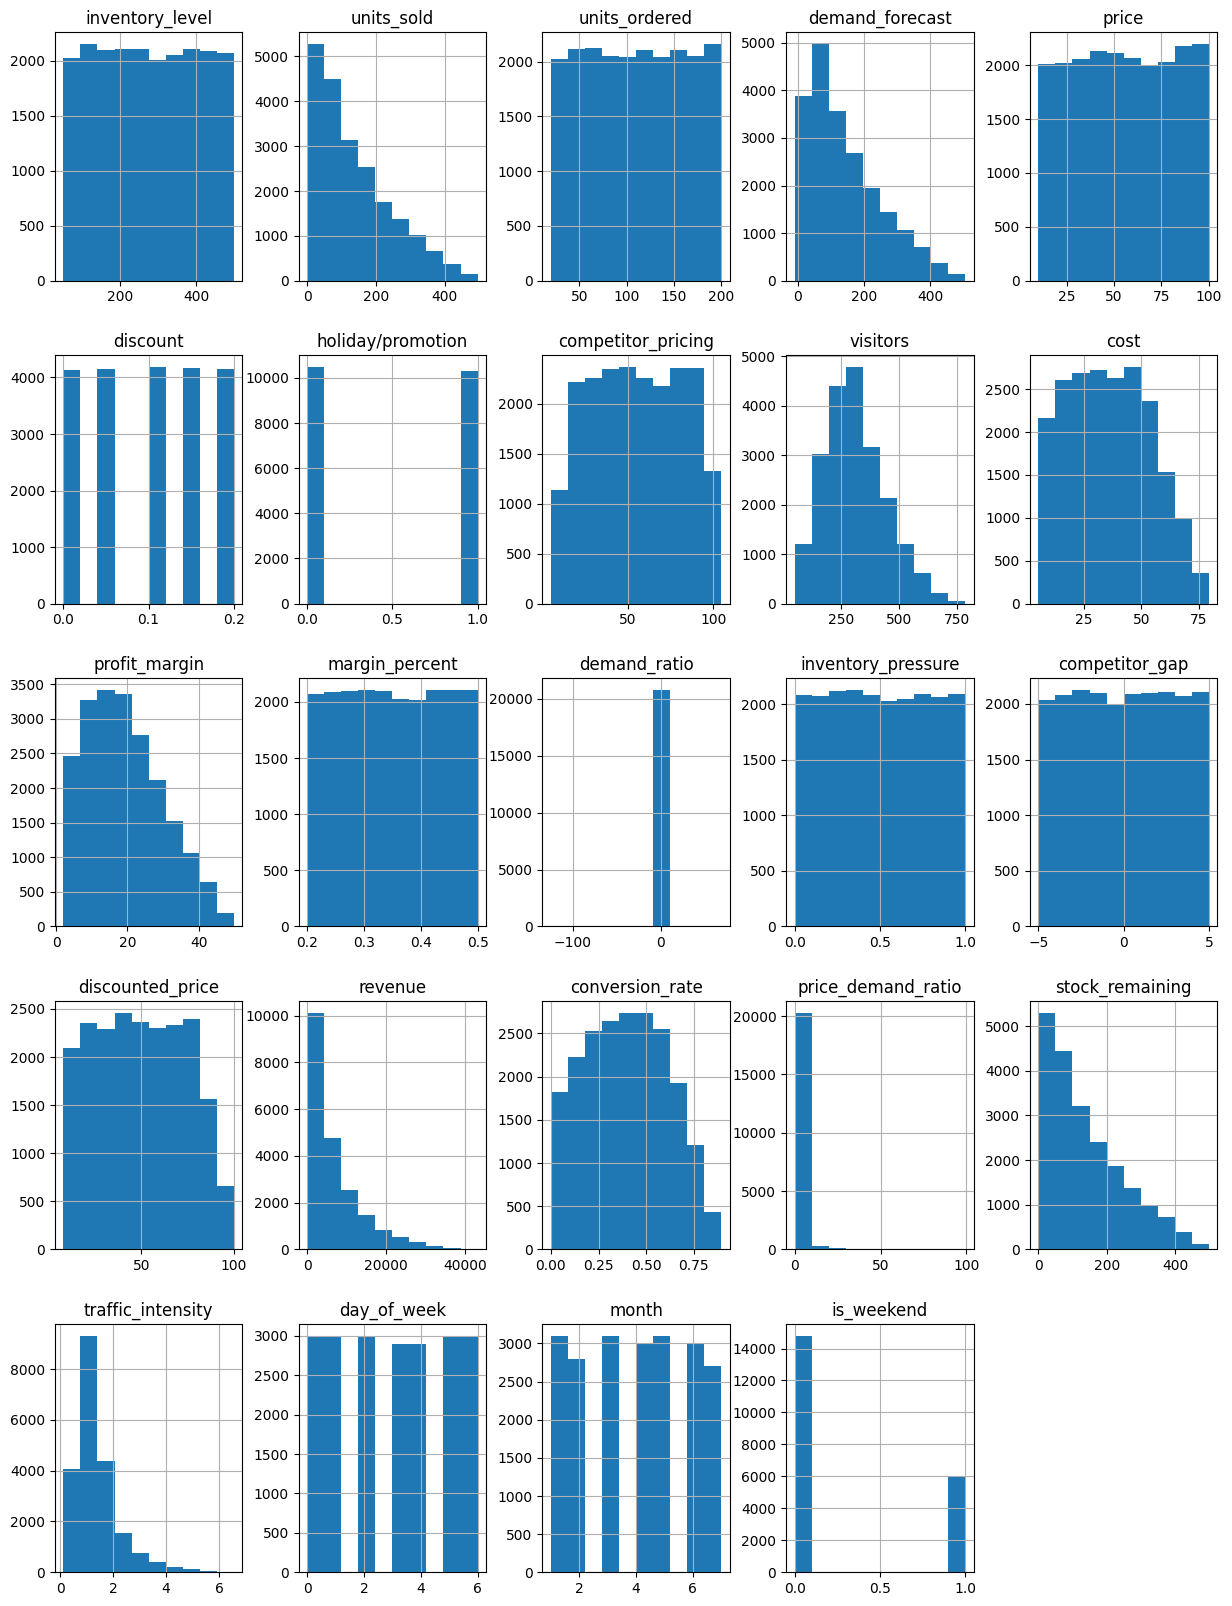

In [ ]:
#Distribution of Numerical Features
df.hist(figsize=(15,20))
plt.show()

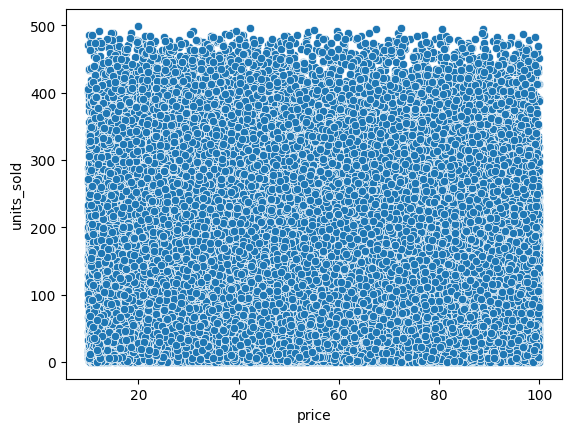

In [ ]:
sns.scatterplot(x="price", y="units_sold", data=df)
plt.show()

key insights:
Price vs Units Sold - >
1) Zero Correlation:
 There is absolutely no discernible relationship between the price of an item
 and the number of units sold. The data points form a solid, rectangular block.
 2) uniform distribution
 3)demand is influenced by a combination of contextual factors captured in engineered features like - demand_ratio, price_demand_ratio, inventory_pressure


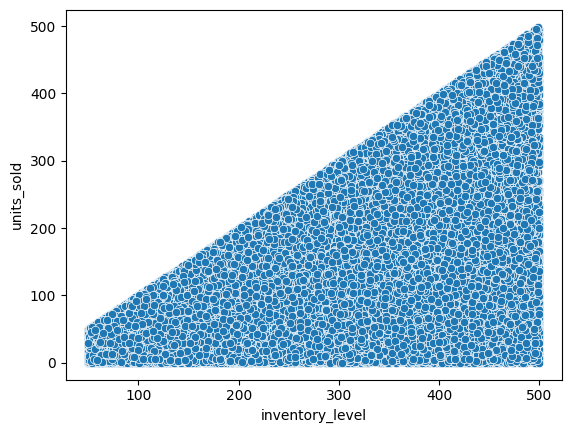

In [ ]:
sns.scatterplot(x="inventory_level", y="units_sold", data=df)
plt.show()

In [ ]:
#When inventory is low (left side, ~50), units sold is also low (0–50). we can't sell what we don't have.
#When inventory is high (right side, ~500), units sold can be anywhere from 0 to 500 -> sometimes high, sometimes low.
#The diagonal ceiling = units sold can never exceed inventory level. ==> units_sold<=inventory_level

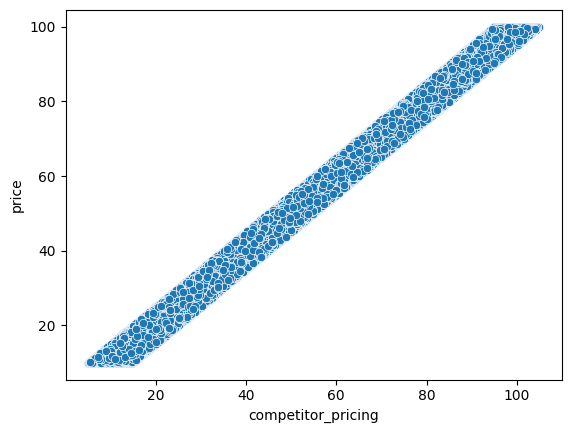

In [ ]:
sns.scatterplot(x="competitor_pricing", y="price", data=df)
plt.show()

key insights : our  price and competitor price move together almost perfectly - this is an extremely high positive correlation (likely r = 0.98 or 0.99 )

In [ ]:
#our pricing strategy in the dataset essentially mirrors competitor pricing with very little deviation

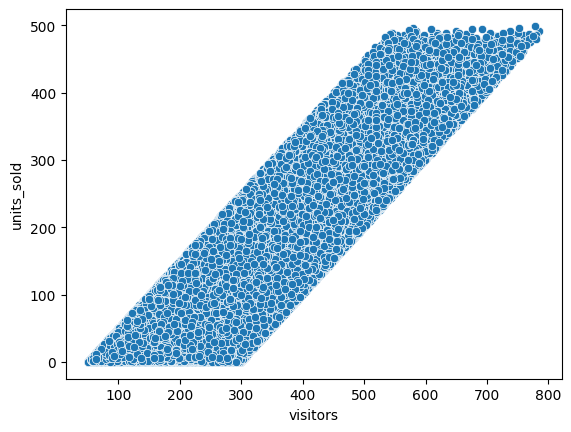

In [ ]:
sns.scatterplot(x="visitors", y="units_sold", data=df)
plt.show()

In [ ]:
#There's a strong positive relationship - more visitors generally leads to more units sold
#The upper boundary = conversion rate ceiling (we can't sell to more people than visit)
#The lower boundary = minimum conversion floor (even with many visitors, some days have low sales)

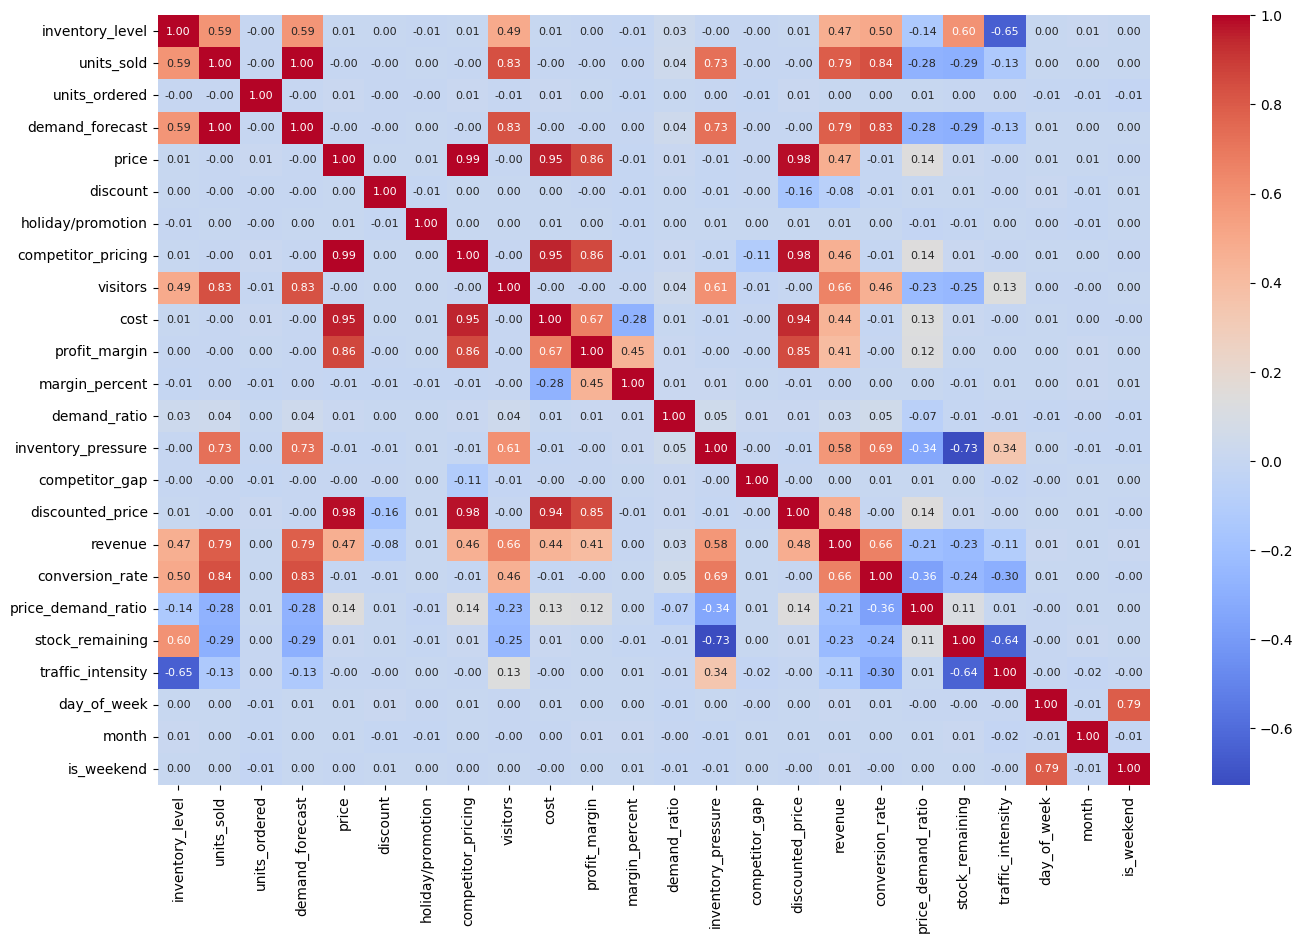

In [ ]:
plt.figure(figsize=(16,10))
sns.heatmap(df.drop(columns=['date','store_id','product_id','category','region','weather_condition','seasonality']).corr(), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 8})
plt.show()

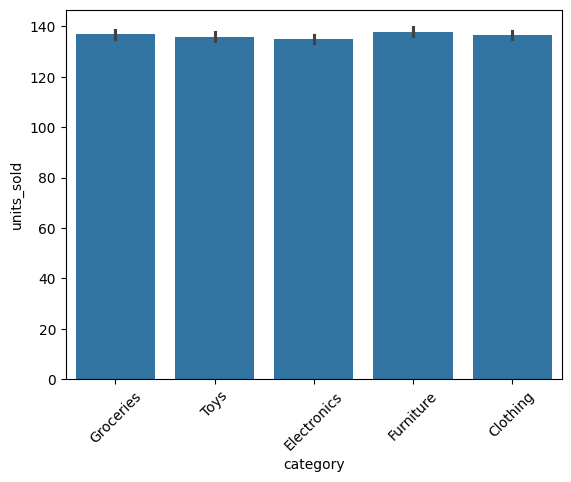

In [ ]:
sns.barplot(x="category", y="units_sold", data=df) #to know high selling categories
plt.xticks(rotation=45)
plt.show()

There's no natural "best category" insight here, barplot is an aggregation chart, by default it considers the mean of y variable. And  All 5 categories (Groceries, Toys, Electronics, Furniture, Clothing) show a mean around 135–138 units sold, which is extremely uniform.

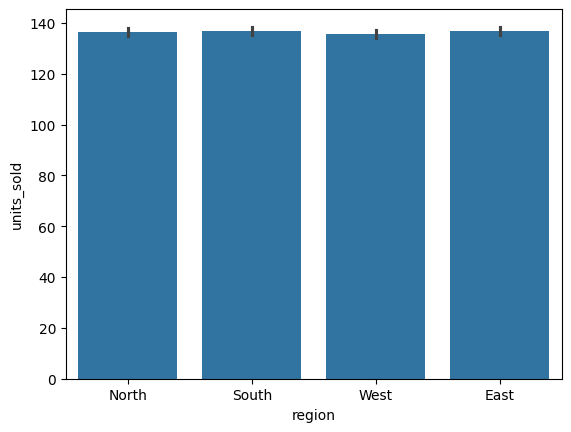

In [ ]:
sns.barplot(x="region", y="units_sold", data=df) # geographic segmentation
plt.show()

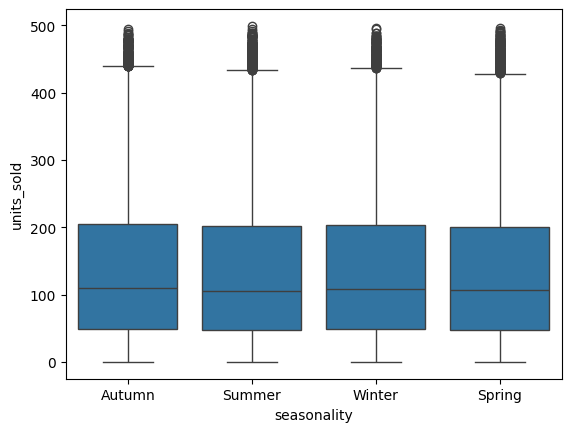

In [ ]:
sns.boxplot(x="seasonality", y="units_sold", data=df)
plt.show()

key insights: Boxplots show the full distribution — median (middle line), interquartile range (box), and outliers (dots beyond whiskers)
all seasons show similar median and spread → seasonality isn't a strong signal alone. If one season has a higher median → that's a pricing opportunity.

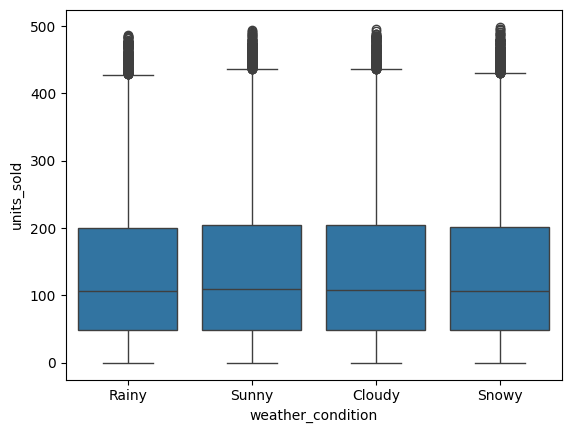

In [ ]:
sns.boxplot(x="weather_condition", y="units_sold", data=df)
plt.show()

all weather conditions show the same distribution → weak feature for the model.

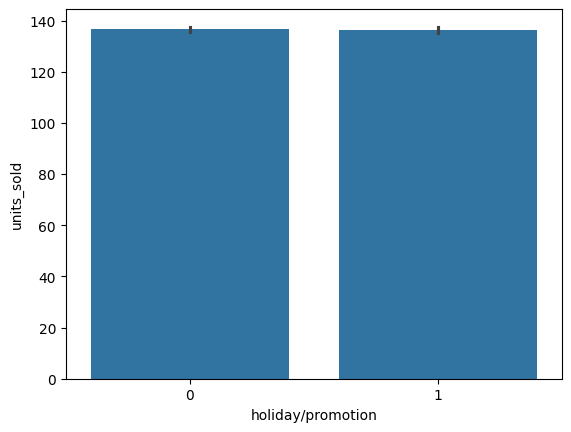

In [ ]:
sns.barplot(x="holiday/promotion", y="units_sold", data=df)
plt.show()

There is almost zero difference in the average number of units sold on regular days versus holidays or promotion days.
Key takeaway: If the bar for 1 is significantly taller than 0 → holidays spike demand → pricing engine should apply surge pricing on holidays.

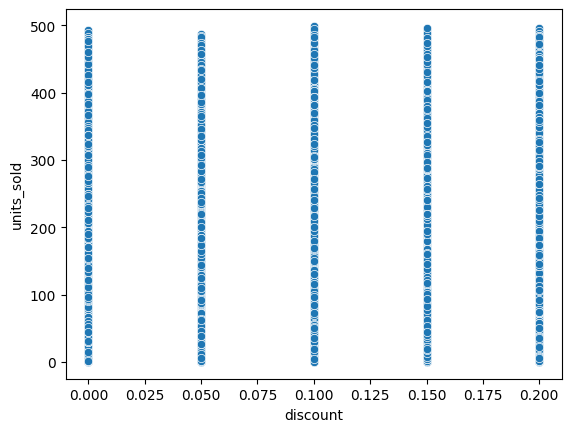

In [ ]:
sns.scatterplot(x="discount", y="units_sold", data=df)
plt.show()

Zero Correlation (Uniform Spread)
every single discount tier spans the exact same range of sales (from 0 to 500 units). * Offering a 20% discount didn't stop some items from selling zero units.

Offering a 0% discount didn't stop some items from selling a massive 500 units.

/tmp/ipykernel_270/2195826862.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="discount", y="units_sold", data=df, palette="Blues")


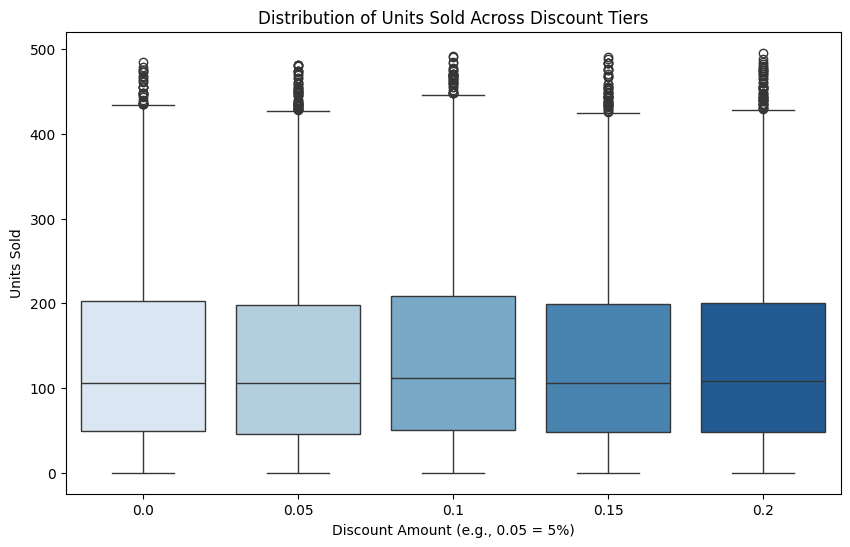

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))

# Create the box plot
# By putting 'discount' on the x-axis, Seaborn automatically treats
# those 5 specific decimal values as distinct categories.
sns.boxplot(x="discount", y="units_sold", data=df, palette="Blues")


plt.title("Distribution of Units Sold Across Discount Tiers")
plt.xlabel("Discount Amount (e.g., 0.05 = 5%)")
plt.ylabel("Units Sold")

# Display the chart
plt.show()

discount strategy did not actually drive higher sales volume.
If the discount IS working: we should see the boxes stepping upward like a staircase. The median line for the 0.20 box should be noticeably higher on the y-axis than the 0.00 box.

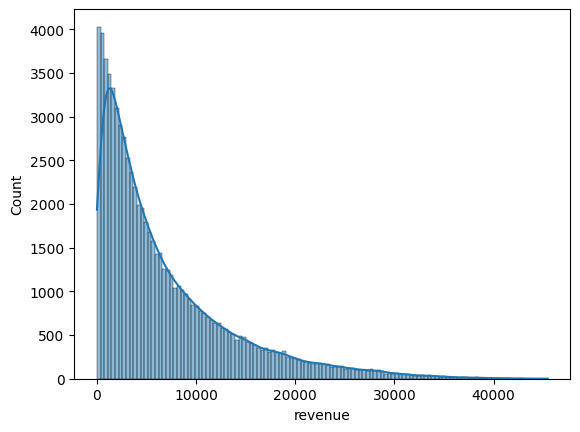

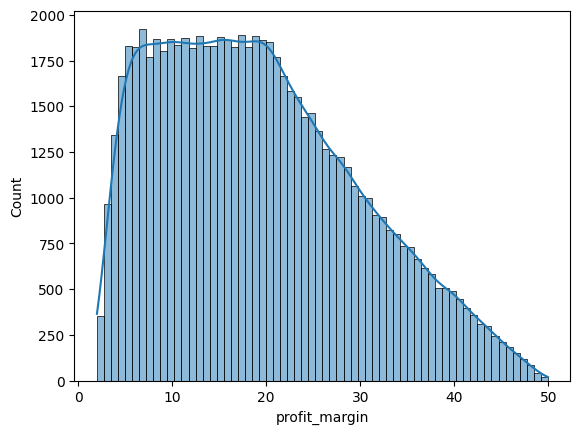

In [ ]:
sns.histplot(df["revenue"], kde=True)
plt.show()

sns.histplot(df["profit_margin"], kde=True)
plt.show()

[Revenue] :- Shape: Heavily Right-Skewed  or positive-skewed distribution.
Head :The massive cluster of tall bars on the far left shows that the vast majority of our data points (days or transactions) result in lower revenue—specifically under the 10,000 mark.
Tail : That long, flattening trail stretching out to 40,000+ represents our extreme outliers. These are rare events where we had unusually massive sales.

[profit_margin]: wide variety of profitable and less-profitable scenarios to learn from, allowing it to accurately weigh how different margins impact overall demand.

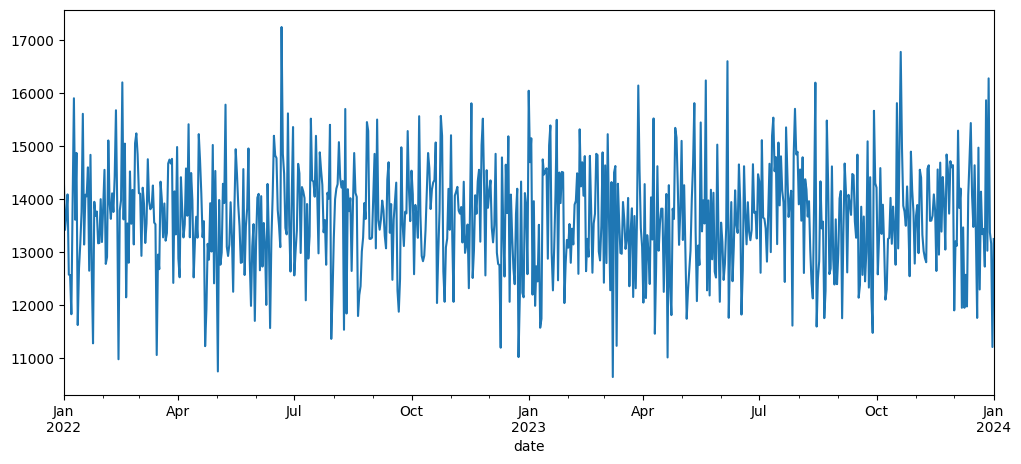

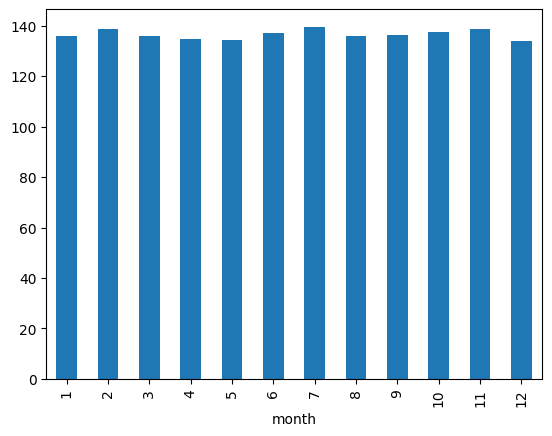

In [ ]:
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")
df.groupby("date")["units_sold"].sum().plot(figsize=(12,5))
plt.show()

df.groupby("month")["units_sold"].mean().plot(kind="bar")
plt.show()

This confirms the lack of seasonality seen in the line chart. The month of the year has absolutely no impact on sales volume in this dataset

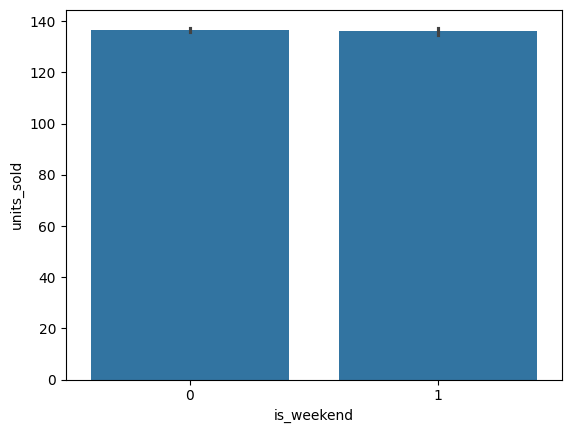

In [ ]:
sns.barplot(x="is_weekend", y="units_sold", data=df)
plt.show()

Similar to the month chart, shopping behavior here does not change on the weekends. In reality, weekend traffic is usually drastically different. This feature will carry almost zero weight in our model.

<Axes: xlabel='conversion_rate', ylabel='Count'>

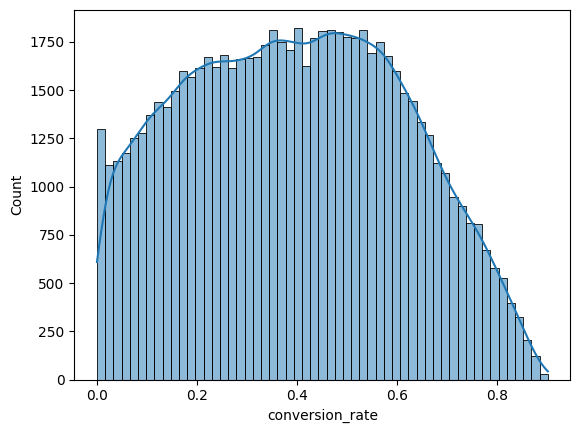

In [ ]:
sns.histplot(df["conversion_rate"], kde=True)

<Axes: xlabel='inventory_pressure', ylabel='Count'>

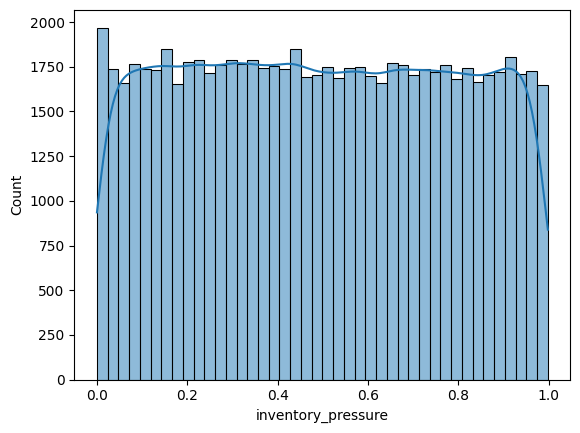

In [ ]:
# Inventory Pressure
sns.histplot(df["inventory_pressure"], kde=True)

inventory_pressure = 0 (Dead Stock)
inventory_pressure = 1 (Complete Sell-Out)

<Axes: xlabel='competitor_gap', ylabel='Count'>

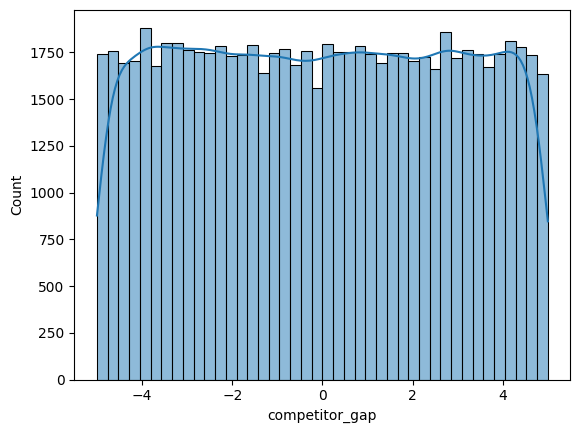

In [ ]:
# Competitor Gap
sns.histplot(df["competitor_gap"], kde=True)

<Axes: xlabel='demand_ratio', ylabel='Count'>

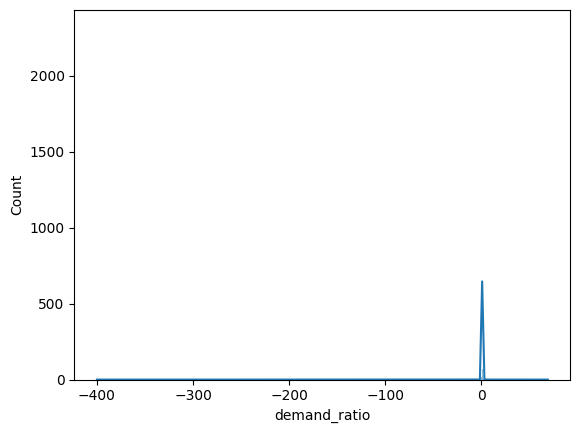

In [ ]:
sns.histplot(df["demand_ratio"], kde=True)

Actual Sales vs. Forecasted Demand: (units_sold / demand_forecast)

A ratio of 1.0 means you sold exactly what you predicted.

A ratio of 1.5 means demand was 50% higher than expected (a great time for the AI to raise prices!).

A ratio of 0.5 means demand was half of what you expected (the AI should lower prices to move inventory).

In [ ]:
#identify key insights

In [ ]:
# Price vs Units Sold - >
# 1) Zero Correlation:
 #There is absolutely no discernible relationship between the price of an item
 #and the number of units sold. The data points form a solid, rectangular block.
 #2) uniform distribution
 #3)demand is influenced by a combination of contextual factors captured in engineered features like - demand_ratio, price_demand_ratio, inventory_pressure


In [ ]:
#Inventory vs Units Sold — Triangle Pattern
#units sold can never exceed inventory level.
#High inventory doesn't guarantee high sales, but low inventory definitely caps sales. This justifies  inventory-based pricing rule -->
#when inventory is low, raise prices to preserve stock; when overstocked, discount to clear stocks.

In [ ]:
#Competitor Pricing Impact — Tight Diagonal Line
#price and competitor price move together almost perfectly — this is an extremely high positive correlation
#our pricing strategy in the dataset essentially mirrors competitor pricing with very little deviation
#competitor_pricing and price are nearly the same signal , use competitor_gap instead of both raw columns together in our  model.

In [ ]:
#Visitors vs Units Sold — Parallelogram Shape
#There's a strong positive relationship - more visitors generally leads to more units sold
#The upper boundary = conversion rate ceiling (we can't sell to more people than visit)
#The lower boundary = minimum conversion floor (even with many visitors, some days have low sales)